## Comparación con los modelos clásicos

In [3]:
import pandas as pd
import networkx as nx
import numpy as np
from scipy.stats import linregress
from pathlib import Path

gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"

# 1. Generate the 30 dates, then slice every 5th date going backwards
all_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")
# Reverse the list and take every 5th element
target_dates = all_dates[::-5] 

print(f"Running topology analysis for {len(target_dates)} sampled snapshots...")
results = []

for ts in target_dates:
    snapshot_key = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{snapshot_key}.parquet"
    
    if not edge_file.exists():
        print(f"  [!] Skipping {snapshot_key}: No data found.")
        continue
        
    print(f"  -> Analyzing {snapshot_key}...")
    edges_df = pd.read_parquet(edge_file)
    G = nx.from_pandas_edgelist(edges_df, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    if G.number_of_nodes() == 0:
        continue

    # --- A. Power Law Fit (In-Degree) ---
    in_degrees = [d for n, d in G.in_degree() if d > 0]
    if len(in_degrees) > 2:
        degree_counts = pd.Series(in_degrees).value_counts().sort_index()
        log_k = np.log10(degree_counts.index.values)
        log_P_k = np.log10(degree_counts.values)
        slope, _, r_val, _, _ = linregress(log_k, log_P_k)
        gamma = -slope
        r_squared = r_val ** 2
    else:
        gamma, r_squared = None, None

    # --- B. Empirical Topology (No more LCC cropping) ---
    G_und = G.to_undirected()
    N = G_und.number_of_nodes()
    M = G_und.number_of_edges()
    
    if N < 10:
        continue
        
    k_avg = 2 * M / N
    emp_C = nx.average_clustering(G_und)
    
    # REPLACED: average_shortest_path_length with global_efficiency
    emp_E = nx.global_efficiency(G_und)

    # --- C. Simulated Models ---
    # 1. Random (Erdős-Rényi)
    p_er = min(1.0, k_avg / (N - 1))
    G_er = nx.erdos_renyi_graph(n=N, p=p_er, seed=42)
    er_C = nx.average_clustering(G_er)
    er_E = nx.global_efficiency(G_er)

    # 2. Small World (Watts-Strogatz)
    k_ws = max(2, int(round(k_avg))) 
    G_ws = nx.watts_strogatz_graph(n=N, k=k_ws, p=0.1, seed=42)
    ws_C = nx.average_clustering(G_ws)
    ws_E = nx.global_efficiency(G_ws)

    # 3. Scale-Free (Barabási-Albert)
    m_ba = max(1, int(round(k_avg / 2)))
    G_ba = nx.barabasi_albert_graph(n=N, m=m_ba, seed=42)
    ba_C = nx.average_clustering(G_ba)
    ba_E = nx.global_efficiency(G_ba)

   
    # --- D. Store Results ---
    results.append({
        'Date': snapshot_key,
        'Nodes (LCC)': N,
        'Avg Degree': round(k_avg, 2),
        'Power Law Gamma': round(gamma, 3) if gamma else None,
        'Power Law R2': round(r_squared, 3) if r_squared else None,
        'Empirical C': round(emp_C, 4),
        'Empirical E': round(emp_E, 4),
        'Random C': round(er_C, 4),
        'Random E': round(er_E, 4),
        'SmallWorld C': round(ws_C, 4),
        'SmallWorld E': round(ws_E, 4),
        'ScaleFree C': round(ba_C, 4),
        'ScaleFree E': round(ba_E, 4)
    })

# Format as a clean DataFrame for easy viewing
df_topology = pd.DataFrame(results).sort_values('Date').reset_index(drop=True)
print("\n🏁 Analysis Complete! Here is the evolution of your network's topology:\n")
display(df_topology)

Running topology analysis for 6 sampled snapshots...
  -> Analyzing 2026-05-06...
  -> Analyzing 2024-12-22...
  -> Analyzing 2023-08-10...
  -> Analyzing 2022-03-28...
  -> Analyzing 2020-11-13...
  -> Analyzing 2019-07-02...

🏁 Analysis Complete! Here is the evolution of your network's topology:



,Date,Nodes (LCC),Avg Degree,Power Law Gamma,Power Law R2,Empirical C,Empirical E,Random C,Random E,SmallWorld C,SmallWorld E,ScaleFree C,ScaleFree E
0,2019-07-02,464,3.18,1.307,0.808,0.1302,0.1859,0.0042,0.1878,0.0000,0.0307,0.0685,0.2958
1,2020-11-13,654,3.44,1.300,0.767,0.1395,0.2146,0.0006,0.1902,0.0000,0.0254,0.0469,0.2797
2,2022-03-28,755,3.63,1.191,0.756,0.1783,0.2292,0.0057,0.1976,0.3722,0.1388,0.0415,0.2746
3,2023-08-10,811,3.65,1.235,0.773,0.1732,0.2234,0.0024,0.1966,0.3786,0.1334,0.0407,0.2717
4,2024-12-22,847,3.66,1.223,0.732,0.1735,0.2286,0.0060,0.1943,0.3790,0.1327,0.0378,0.2699
5,2026-05-06,901,3.76,1.244,0.738,0.1846,0.2429,0.0030,0.1966,0.3782,0.1264,0.0338,0.2670


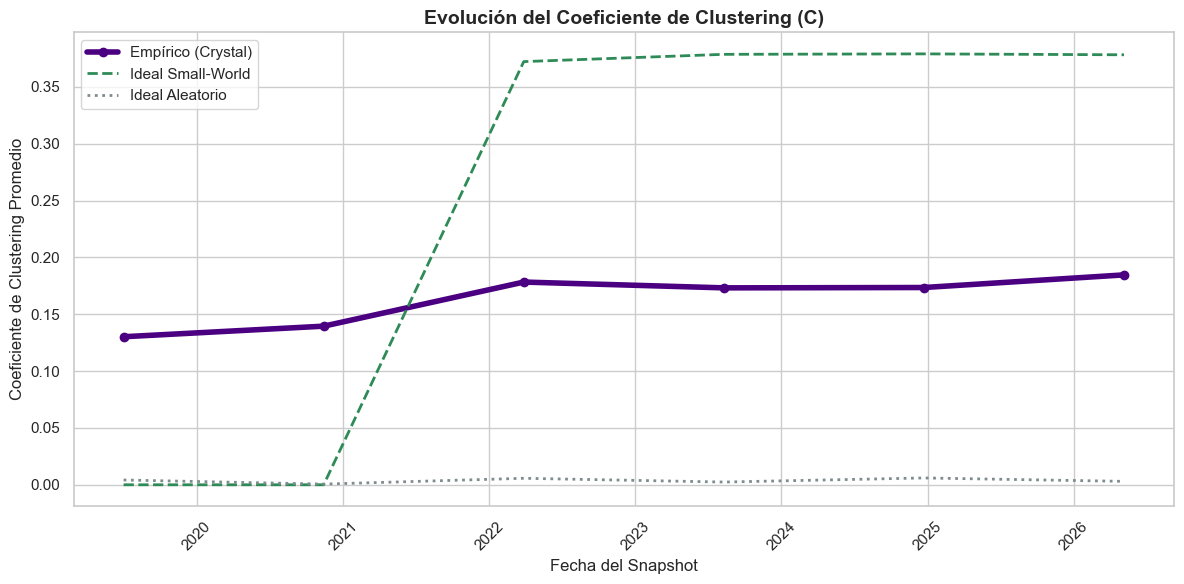

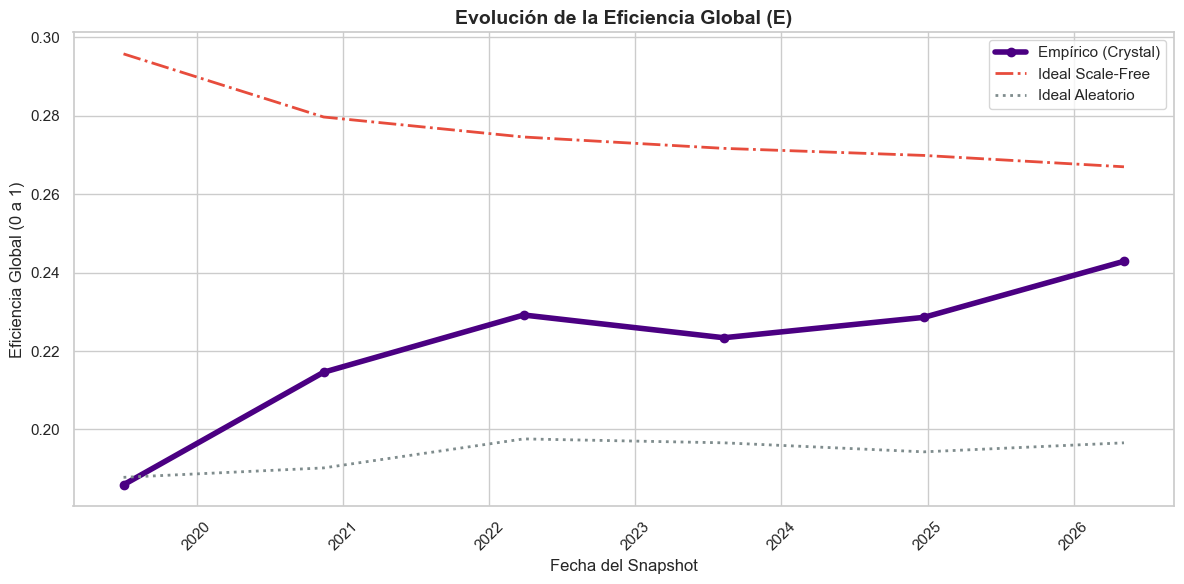

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual limpia
sns.set_theme(style="whitegrid")

# Asegurar que Date sea un objeto datetime para un eje X cronológico
df_topology['Date'] = pd.to_datetime(df_topology['Date'])

# --- Gráfico 1: Coeficiente de Clustering (C) ---
plt.figure(figsize=(12, 6))

plt.plot(df_topology['Date'], df_topology['Empirical C'], label='Empírico (Crystal)', linewidth=4, color='#4B0082', marker='o')
plt.plot(df_topology['Date'], df_topology['SmallWorld C'], label='Ideal Small-World', linestyle='--', linewidth=2, color='#2E8B57')
plt.plot(df_topology['Date'], df_topology['Random C'], label='Ideal Aleatorio', linestyle=':', linewidth=2, color='#7F8C8D')

plt.title("Evolución del Coeficiente de Clustering (C)", fontsize=14, fontweight='bold')
plt.ylabel("Coeficiente de Clustering Promedio", fontsize=12)
plt.xlabel("Fecha del Snapshot", fontsize=12)
plt.legend(fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- Gráfico 2: Eficiencia Global (E) ---
plt.figure(figsize=(12, 6))

plt.plot(df_topology['Date'], df_topology['Empirical E'], label='Empírico (Crystal)', linewidth=4, color='#4B0082', marker='o')
plt.plot(df_topology['Date'], df_topology['ScaleFree E'], label='Ideal Scale-Free', linestyle='-.', linewidth=2, color='#E74C3C')
plt.plot(df_topology['Date'], df_topology['Random E'], label='Ideal Aleatorio', linestyle=':', linewidth=2, color='#7F8C8D')

plt.title("Evolución de la Eficiencia Global (E)", fontsize=14, fontweight='bold')
plt.ylabel("Eficiencia Global (0 a 1)", fontsize=12)
plt.xlabel("Fecha del Snapshot", fontsize=12)
plt.legend(fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

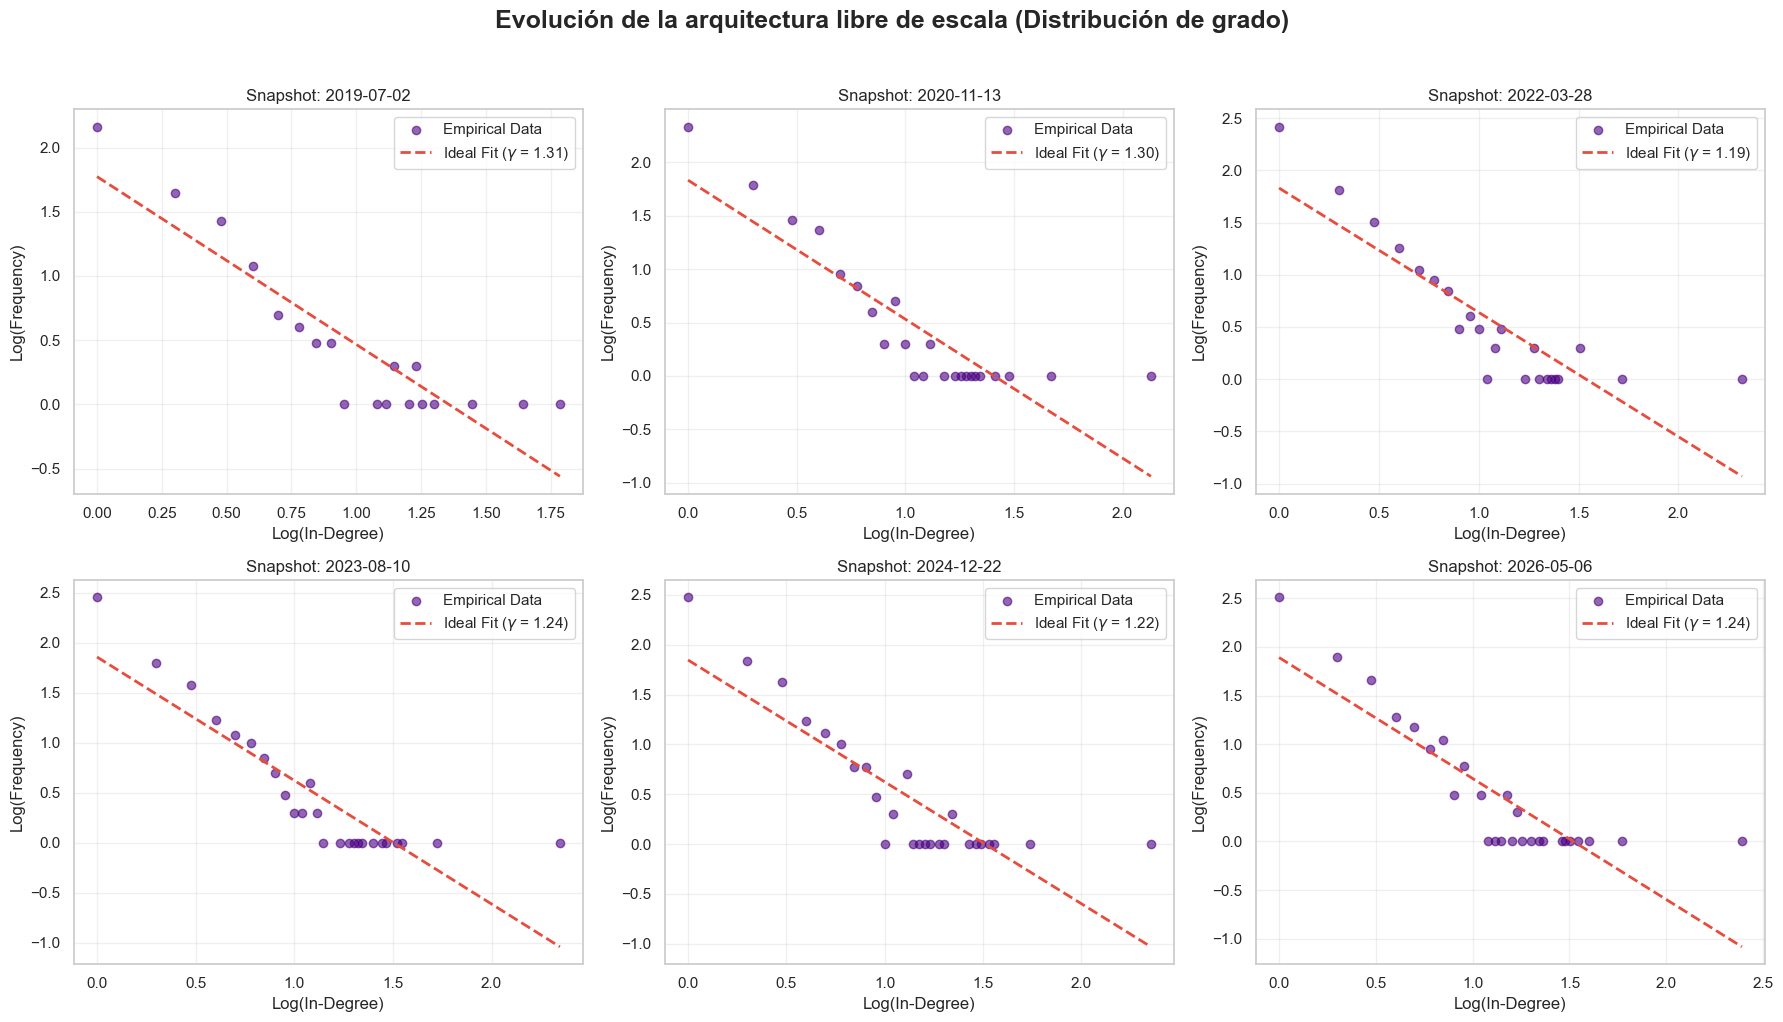

In [5]:
# QQ plot para bondad de ajuste con distribución de potencia 
# 6 cortes temporales


import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

gold_dir = Path("data/03_gold")

# Re-fetch the 6 target dates so we can pull the raw edges
anchor_date = "2026-05-06"
all_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")
target_dates = all_dates[::-5][::-1] # Grab the 6, and reverse to chronologically order them

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

fig.suptitle("Evolución de la arquitectura libre de escala (Distribución de grado)", fontsize=18, fontweight='bold', y=1.02)

for i, ts in enumerate(target_dates):
    snapshot_key = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{snapshot_key}.parquet"
    
    if not edge_file.exists():
        continue
        
    edges_df = pd.read_parquet(edge_file)
    G = nx.from_pandas_edgelist(edges_df, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    in_degrees = [d for n, d in G.in_degree() if d > 0]
    
    if len(in_degrees) > 2:
        degree_counts = pd.Series(in_degrees).value_counts().sort_index()
        k = degree_counts.index.values
        P_k = degree_counts.values
        
        # Log transformation
        log_k = np.log10(k)
        log_P_k = np.log10(P_k)
        
        # Calculate ideal slope
        slope, intercept, r_val, _, _ = linregress(log_k, log_P_k)
        ideal_line = (slope * log_k) + intercept
        
        # Plotting
        ax = axes[i]
        ax.scatter(log_k, log_P_k, color='#4B0082', alpha=0.6, label='Empirical Data')
        ax.plot(log_k, ideal_line, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ideal Fit ($\gamma$ = {-slope:.2f})')
        
        ax.set_title(f"Snapshot: {snapshot_key}", fontsize=12)
        ax.set_xlabel("Log(In-Degree)")
        ax.set_ylabel("Log(Frequency)")
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()